In [20]:
import pandas as pd
import matplotlib.pyplot as plt 
import random

In [21]:
df = pd.read_csv("/Users/zakariaebahaji/Documents/Sales Data Analysis Dashboard/data/jordan_market_dataset_2026.csv")
df

,Transaction_ID,Sale_Date,Shoe_Model,Colorway,Condition,Retail_Price_USD,Resale_Price_USD,Sales_Channel,Days_in_Inventory,Profit_Margin_USD,Customer_ID
0,TRX-100001,2024-10-23,Air Jordan 11 Retro,Sail,Used,225,194.67,GOAT,13,-30.33,74
1,TRX-100002,2023-10-23,Air Jordan 1 High,Mocha,Deadstock (Brand New),185,230.46,StockX,10,45.46,47
2,TRX-100003,2023-11-13,Air Jordan 4 Retro,Concord,Deadstock (Brand New),212,270.37,kick hub 2026,33,58.37,77
3,TRX-100004,2024-02-01,Air Jordan 4 Retro,Mocha,Used,223,180.43,Stadium Goods,60,-42.57,1
4,TRX-100005,2023-05-29,Air Jordan 1 Low,Mocha,Used,137,117.43,kick hub 2026,30,-19.57,82
...,...,...,...,...,...,...,...,...,...,...,...
4995,TRX-104996,2023-02-17,Air Jordan 1 Low,Pine Green,Used,130,65.15,GOAT,11,-64.85,65
4996,TRX-104997,2023-06-24,Air Jordan 1 Low,Chicago,Deadstock (Brand New),114,268.05,GOAT,9,154.05,71
4997,TRX-104998,2024-06-12,Air Jordan 4 Retro,Lost & Found,Deadstock (Brand New),222,405.55,StockX,9,183.55,38
4998,TRX-104999,2024-06-19,Air Jordan 1 High,Black Cat,Used,171,137.27,Walk-in Retail,24,-33.73,89


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Transaction_ID     5000 non-null   object 
 1   Sale_Date          5000 non-null   object 
 2   Shoe_Model         5000 non-null   object 
 3   Colorway           5000 non-null   object 
 4   Condition          5000 non-null   object 
 5   Retail_Price_USD   5000 non-null   int64  
 6   Resale_Price_USD   5000 non-null   float64
 7   Sales_Channel      5000 non-null   object 
 8   Days_in_Inventory  5000 non-null   int64  
 9   Profit_Margin_USD  5000 non-null   float64
 10  Customer_ID        5000 non-null   int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 429.8+ KB


In [23]:
df.describe()

,Retail_Price_USD,Resale_Price_USD,Days_in_Inventory,Profit_Margin_USD,Customer_ID
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,191.172400,273.230512,22.472600,82.058112,50.734400
std,37.099191,167.237989,17.741449,159.073822,28.940079
min,110.000000,55.910000,1.000000,-114.350000,1.000000
25%,175.000000,148.487500,8.000000,-37.122500,26.000000
50%,205.000000,226.160000,14.000000,35.270000,51.000000
75%,221.000000,333.950000,37.000000,153.090000,76.000000
max,230.000000,804.580000,60.000000,574.580000,100.000000


#  **channel performs best**

In [24]:
channel_performance = df.groupby("Sales_Channel")[["Resale_Price_USD","Profit_Margin_USD"]].sum()
channel_performance = channel_performance.sort_values("Profit_Margin_USD",ascending=False)


print(channel_performance)

                Resale_Price_USD  Profit_Margin_USD
Sales_Channel                                      
Walk-in Retail         280361.39           89281.39
GOAT                   285392.02           85054.02
Stadium Goods          267705.50           81122.50
kick hub 2026          260086.63           78912.63
StockX                 272607.02           75920.02


# **Sales Channel Performance**

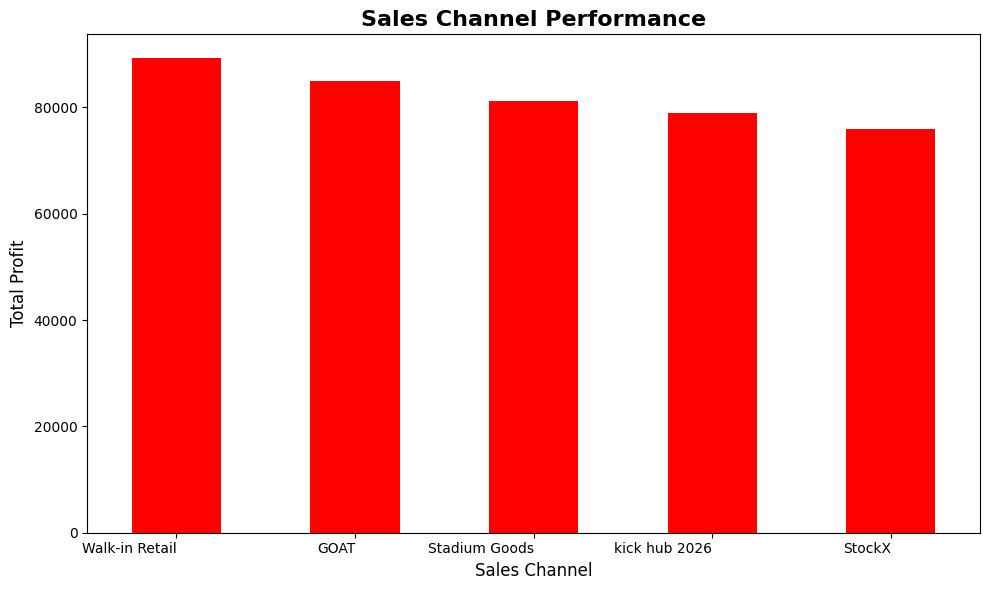

✓ Chart 1 saved: 01_channel_performance.png


In [25]:
plt.figure(figsize=(10,6))

channel_performance["Profit_Margin_USD"].plot(kind="bar",color="red",legend=False)
plt.title("Sales Channel Performance", fontsize = 16, fontweight = "bold")
plt.xlabel("Sales Channel",fontsize = 12)
plt.ylabel("Total Profit", fontsize = 12)

plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.savefig('charts/01_channel_performance.png', dpi=300, bbox_inches='tight')

plt.show()

print("✓ Chart 1 saved: 01_channel_performance.png")

#  **shoe model is most profitable**

In [26]:
shoe_performance = df.groupby("Shoe_Model")[["Profit_Margin_USD"]].sum()
shoe_performance = shoe_performance.sort_values("Profit_Margin_USD",ascending=False)
print(shoe_performance.head(10))

                     Profit_Margin_USD
Shoe_Model                            
Air Jordan 4 Retro            99974.28
Air Jordan 11 Retro           97140.78
Air Jordan 3 Retro            85850.95
Air Jordan 1 High             75792.74
Air Jordan 1 Low              51531.81


#  **Top 10 Shoe Models (Horizontal Bar Chart)**

<Figure size 1200x600 with 0 Axes>

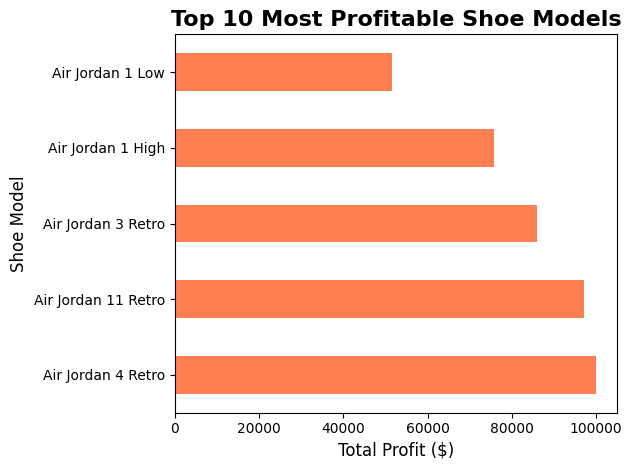

✓ Chart 2 saved: 02_top_shoe_models.png


In [27]:
plt.figure(figsize=(12, 6))
shoe_performance.head(10).plot(kind='barh', color='coral', legend=False)
plt.title('Top 10 Most Profitable Shoe Models', fontsize=16, fontweight='bold')
plt.xlabel('Total Profit ($)', fontsize=12)
plt.ylabel('Shoe Model', fontsize=12)
plt.tight_layout()
plt.savefig('charts/02_top_shoe_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart 2 saved: 02_top_shoe_models.png")

#  **Monthly Sales Trend (across all years)**

In [28]:
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"])

# Group by month and sum profit
monthly_trend = df.groupby(df["Sale_Date"].dt.to_period("M"))[["Profit_Margin_USD"]].sum()

print("Monthly Sales Trend (across all years):")
print(monthly_trend.head(5))

Monthly Sales Trend (across all years):
           Profit_Margin_USD
Sale_Date                   
2023-01             13138.80
2023-02             12450.33
2023-03             13760.17
2023-04              9508.56
2023-05             11682.07


#  **Monthly Sales Trend (Line Chart)**

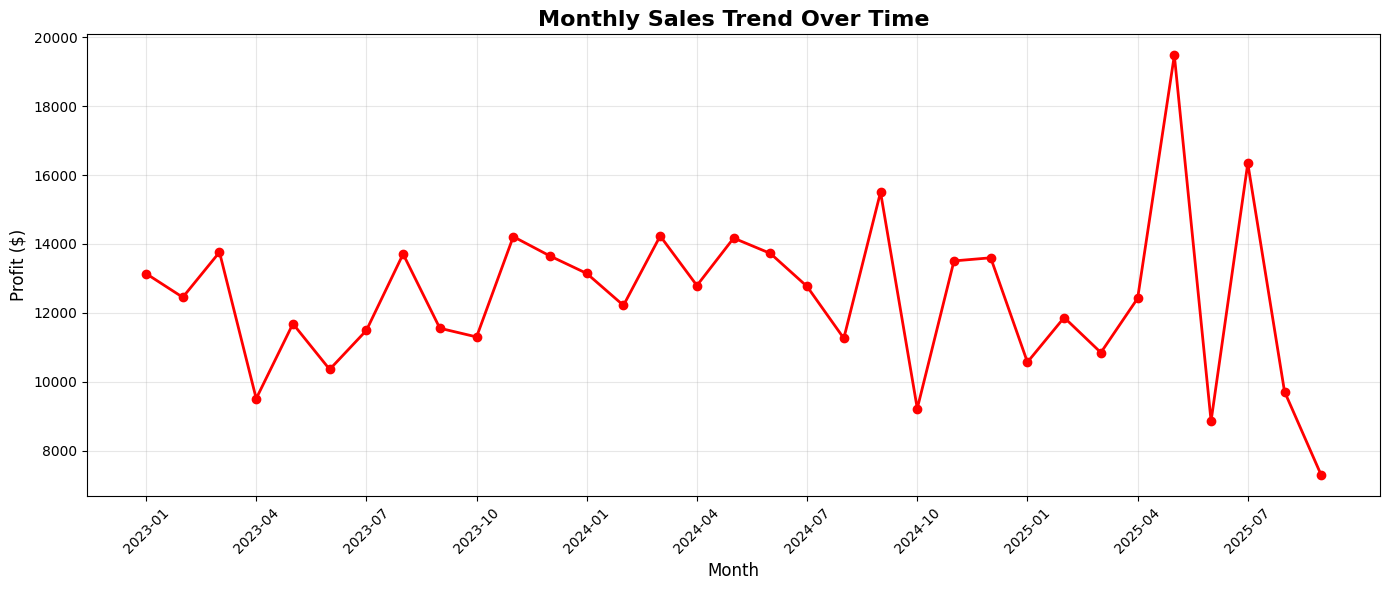

✓ Chart 3 saved: 03_monthly_trend.png


In [29]:
plt.figure(figsize=(14, 6))
monthly_trend_sorted = monthly_trend.sort_index()

plt.plot(range(len(monthly_trend_sorted)), monthly_trend_sorted['Profit_Margin_USD'].values, marker='o', linewidth=2, markersize=6, color='red')

plt.title('Monthly Sales Trend Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)

plt.xticks(range(0,len(monthly_trend_sorted),3), [str(idx)for idx in monthly_trend_sorted.index[::3]] , rotation=45 )

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('charts/03_monthly_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart 3 saved: 03_monthly_trend.png")


#  **condition (Deadstock, VNDS, Used) has better profit margins** 

In [30]:
condition_performance = df.groupby("Condition")[["Profit_Margin_USD"]].agg(["sum","mean","count"])
condition_performance.columns = ["Total_Profit","AVG_Profit","Transaction_Count"]
condition_performance = condition_performance.sort_values("Total_Profit",ascending=False)

print("Profit by Shoe Condition: ")
print(condition_performance)

Profit by Shoe Condition: 
                            Total_Profit  AVG_Profit  Transaction_Count
Condition                                                              
Deadstock (Brand New)          443001.14  264.005447               1678
VNDS (Very Near Deadstock)      62716.19   37.622190               1667
Used                           -95426.77  -57.659680               1655


#  **Shoe Condition Impact (Bar Chart)**

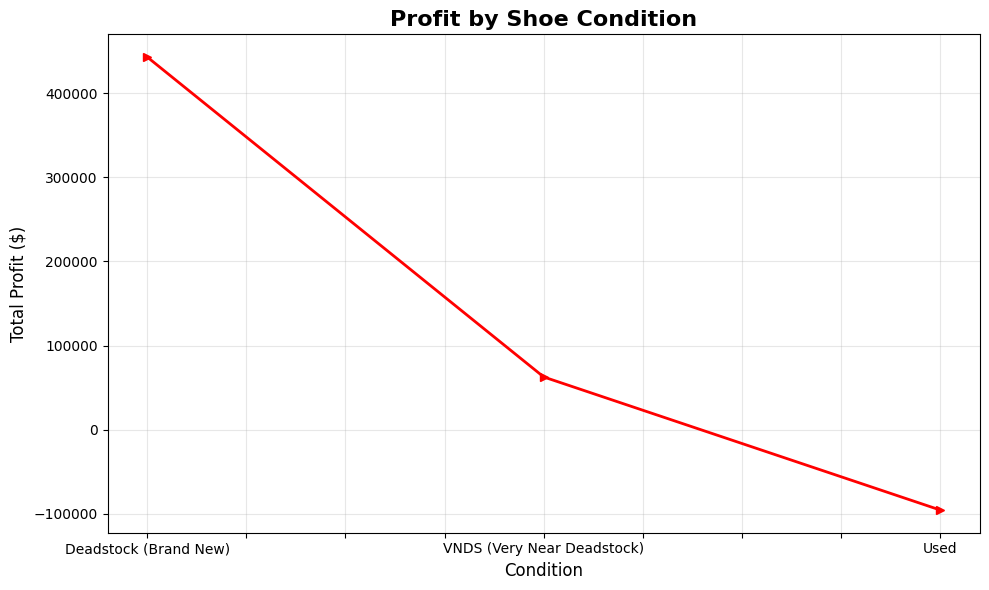

✓ Chart 5 saved: 05_condition_impact.png


In [31]:
plt.figure(figsize=(10,6))
condition_performance["Total_Profit"].plot(kind="line",linewidth=2,marker=">",color="red",legend=False)

plt.title("Profit by Shoe Condition", fontsize=16,fontweight="bold")
plt.xlabel("Condition",fontsize=12)
plt.ylabel("Total Profit ($)",fontsize=12)

plt.grid(True,alpha=0.3)
plt.tight_layout()

plt.savefig('charts/05_condition_impact.png', dpi=300, bbox_inches='tight')

plt.show()

print("✓ Chart 5 saved: 05_condition_impact.png")

#  **Most Valuable Customers**

In [32]:
customer_performance = df.groupby("Customer_ID")[["Profit_Margin_USD"]].sum()
customer_performance.columns = ["Total_Profit"]
customer_performance = customer_performance.sort_values("Total_Profit", ascending=False)

print("Top 10 Most Valuable Customers:")
print(customer_performance.head(10))

Top 10 Most Valuable Customers:
             Total_Profit
Customer_ID              
19                7962.88
73                7446.99
70                7061.90
67                6623.46
29                6256.82
21                6189.12
76                5938.70
46                5883.05
14                5824.58
100               5811.19


#  **Top 10 Customers (Bar Chart)**

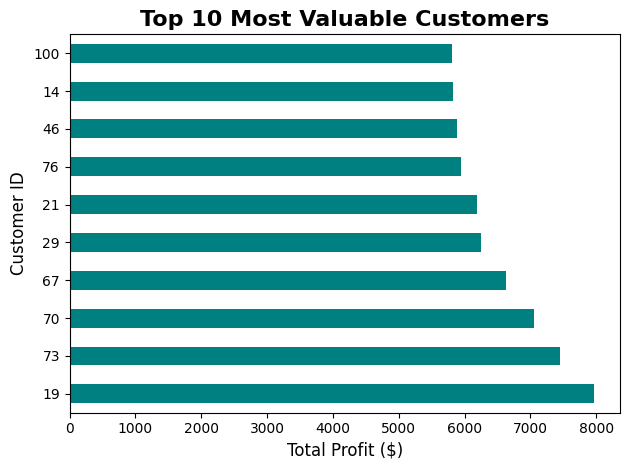

✓ Chart 6 saved: 06_top_customers.png


In [33]:
customer_performance.head(10).plot(kind="barh",color="teal",legend=False)

plt.title('Top 10 Most Valuable Customers', fontsize=16, fontweight='bold')
plt.xlabel('Total Profit ($)', fontsize=12)
plt.ylabel('Customer ID', fontsize=12)

plt.tight_layout()
plt.savefig('charts/06_top_customers.png', dpi=300, bbox_inches='tight')

plt.show()

print("✓ Chart 6 saved: 06_top_customers.png")

#  **Retail vs Resale Price Comparison**

In [34]:
price_comparison = df[["Retail_Price_USD","Resale_Price_USD"]].describe()

print("Price Comparison Statistics: ")
print(price_comparison)

# Calculate AVG Markup/Markdown 

avg_markup = ( df["Resale_Price_USD"].mean() - df["Retail_Price_USD"].mean() ) / df["Retail_Price_USD"].mean() * 100

print(f"\nAverage Resale vs Retail:")

print(f"Retail Price (avg): ${df['Retail_Price_USD'].mean():.2f}")

print(f"Resale Price (avg): ${df['Resale_Price_USD'].mean():.2f}")

print(f"Average Markup/Markdown: {avg_markup :+.2f}%" )

Price Comparison Statistics: 
       Retail_Price_USD  Resale_Price_USD
count       5000.000000       5000.000000
mean         191.172400        273.230512
std           37.099191        167.237989
min          110.000000         55.910000
25%          175.000000        148.487500
50%          205.000000        226.160000
75%          221.000000        333.950000
max          230.000000        804.580000

Average Resale vs Retail:
Retail Price (avg): $191.17
Resale Price (avg): $273.23
Average Markup/Markdown: +42.92%


#  **Retail vs Resale Price Distribution (Histogram)**

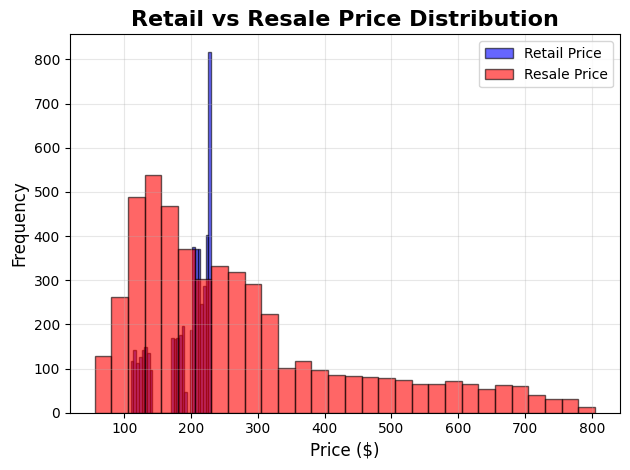

✓ Chart 7 saved: 07_price_distribution.png


In [35]:
plt.hist(df['Retail_Price_USD'], bins=30, alpha=0.6, label='Retail Price', color='blue', edgecolor='black')
plt.hist(df['Resale_Price_USD'], bins=30, alpha=0.6, label='Resale Price', color='red', edgecolor='black')

plt.title('Retail vs Resale Price Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('charts/07_price_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

print("✓ Chart 7 saved: 07_price_distribution.png")

# **Yearly Sales**

In [36]:
profit_year = df.groupby(df["Sale_Date"].dt.year)[["Profit_Margin_USD"]].sum()
profit_year.columns = ["Profit_per_year"]

print("Year_sales_trend: ")
print(profit_year)

print(f"\nYear-over-year growth:")

for i in range(1, len(profit_year)):
    curr_year = profit_year.index[i]
    prev_year = profit_year.index[i-1]
    curr_profit = profit_year.iloc[i,0]
    prev_profit = profit_year.iloc[i-1,0]
    
    growth = ((curr_profit - prev_profit) / prev_profit) * 100
    
    print(f"{prev_year} -> {curr_year} == {growth:+.2f}%")

Year_sales_trend: 
           Profit_per_year
Sale_Date                 
2023             146803.93
2024             156124.15
2025             107362.48

Year-over-year growth:
2023 -> 2024 == +6.35%
2024 -> 2025 == -31.23%


#  **Yearly Sales Trend (Bar Chart)**

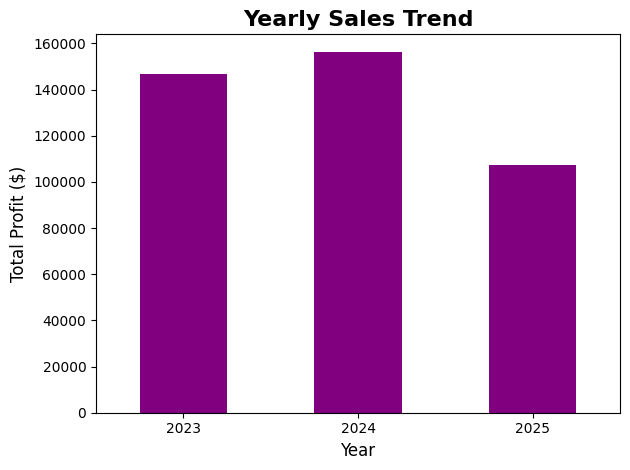

✓ Chart 8 saved: 04_yearly_trend.png


In [37]:
profit_year["Profit_per_year"].plot(kind="bar",color="purple",legend=False)

plt.title('Yearly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/08_yearly_trend.png', dpi=300, bbox_inches='tight')

plt.show()

print("✓ Chart 8 saved: 04_yearly_trend.png")

In [38]:
print("="*70)
print("SALES DATA ANALYSIS DASHBOARD - FINAL REPORT")
print("="*70)

print("\n📊 ANALYSIS #1: SALES CHANNEL PERFORMANCE")
print("-" * 70)
print(channel_performance)
print(f"\n💡 Insight: {channel_performance.index[0]} is the top performer with ${channel_performance['Profit_Margin_USD'].iloc[0]:,.2f} profit")

print("\n\n📊 ANALYSIS #2: TOP 10 MOST PROFITABLE SHOE MODELS")
print("-" * 70)
print(shoe_performance.head(10))
print(f"\n💡 Insight: {shoe_performance.index[0]} generates the most profit at ${shoe_performance['Profit_Margin_USD'].iloc[0]:,.2f}")

print("\n\n📊 ANALYSIS #3: YEARLY SALES TREND")
print("-" * 70)
print(profit_year)
print(f"\n💡 Insight: Total profit across all years: ${profit_year['Profit_per_year'].sum():,.2f}")

print("\n\n📊 ANALYSIS #4: MONTHLY SALES TREND")
print("-" * 70)
print(f"Months analyzed: {len(monthly_trend)}")
print(f"Highest profit month: {monthly_trend['Profit_Margin_USD'].idxmax()} with ${monthly_trend['Profit_Margin_USD'].max():,.2f}")
print(f"Lowest profit month: {monthly_trend['Profit_Margin_USD'].idxmin()} with ${monthly_trend['Profit_Margin_USD'].min():,.2f}")
print(f"Average monthly profit: ${monthly_trend['Profit_Margin_USD'].mean():,.2f}")

print("\n\n📊 ANALYSIS #5: SHOE CONDITION IMPACT")
print("-" * 70)
print(condition_performance)
best_condition = condition_performance['Total_Profit'].idxmax()
print(f"\n💡 Insight: '{best_condition}' condition generates the most profit")

print("\n\n📊 ANALYSIS #6: TOP 10 MOST VALUABLE CUSTOMERS")
print("-" * 70)
print(customer_performance.head(10))
print(f"\n💡 Insight: Top customer is {customer_performance.index[0]} with ${customer_performance['Total_Profit'].iloc[0]:,.2f} profit")

print("\n\n📊 ANALYSIS #7: RETAIL VS RESALE PRICE COMPARISON")
print("-" * 70)
print(price_comparison)
print(f"\nAverage Retail Price: ${df['Retail_Price_USD'].mean():,.2f}")
print(f"Average Resale Price: ${df['Resale_Price_USD'].mean():,.2f}")
avg_markup = (df['Resale_Price_USD'].mean() - df['Retail_Price_USD'].mean()) / df['Retail_Price_USD'].mean() * 100
print(f"Average Markup: {avg_markup:+.2f}%")
print(f"\n💡 Insight: Sneakers are resold at {avg_markup:.1f}% higher than retail price on average!")

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE!")
print("="*70)
print("\n📁 All charts saved to: charts/")
print("📊 Total rows analyzed: 5,000 transactions")
print("💾 Files created:")
print("   ✓ 01_channel_performance.png")
print("   ✓ 02_top_shoe_models.png")
print("   ✓ 03_monthly_trend.png")
print("   ✓ 04_yearly_trend.png")
print("   ✓ 05_condition_impact.png")
print("   ✓ 06_top_customers.png")
print("   ✓ 07_price_distribution.png")

SALES DATA ANALYSIS DASHBOARD - FINAL REPORT

📊 ANALYSIS #1: SALES CHANNEL PERFORMANCE
----------------------------------------------------------------------
                Resale_Price_USD  Profit_Margin_USD
Sales_Channel                                      
Walk-in Retail         280361.39           89281.39
GOAT                   285392.02           85054.02
Stadium Goods          267705.50           81122.50
kick hub 2026          260086.63           78912.63
StockX                 272607.02           75920.02

💡 Insight: Walk-in Retail is the top performer with $89,281.39 profit


📊 ANALYSIS #2: TOP 10 MOST PROFITABLE SHOE MODELS
----------------------------------------------------------------------
                     Profit_Margin_USD
Shoe_Model                            
Air Jordan 4 Retro            99974.28
Air Jordan 11 Retro           97140.78
Air Jordan 3 Retro            85850.95
Air Jordan 1 High             75792.74
Air Jordan 1 Low              51531.81

💡 Insight: